## Using RNNs to classify sentiment on IMDB data

In this assignment,you will train three types of RNNs:  "vanilla" RNN, LSTM and GRU to predict the sentiment on IMDB reviews.  

Keras provides a convenient interface to load the data and immediately encode the words into integers (based on the most common words). 
This will save you a lot of the drudgery that is usually involved when working with raw text.

The IMDB is  data consists of 25000 training sequences and 25000 test sequences. 
The outcome is binary (positive/negative) and both outcomes are equally represented in both the training and the test set.


Walk through the followinng steps to prepare the data and the building of an RNN model. 

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import time
import tensorflow as tf
from tensorflow.keras import Sequential, layers, optimizers, initializers
from tensorflow.keras.datasets import imdb
from tensorflow.keras.preprocessing.sequence import pad_sequences


tf.keras.utils.set_random_seed(42)


2026-07-28 08:14:30.262968: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:485] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2026-07-28 08:14:30.270782: E external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:8473] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2026-07-28 08:14:30.274455: E external/local_xla/xla/stream_executor/cuda/cuda_blas.cc:1471] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2026-07-28 08:14:31.110008: W tensorflow/compiler/tf2tensorrt/utils/py_utils.cc:38] TF-TRT Warning: Could not find TensorRT: INTERNAL: Cannot dlopen all TensorRT libraries: FAILED_PRECONDITION: Could not load dynamic library 'libnvinfer.so.10.8.0'; dlerror: libnvinfer.so.10.8.0: cannot open shared object file: No such file or directory


1- Use the `imdb.load_data()` to load in the data 

2- Specify the maximum length of a sequence to 30 words and the pick the 2000 most common words. 

In [2]:
max_features = 2000
maxlen = 30

(x_train, y_train), (x_test, y_test) = imdb.load_data(num_words=max_features)

print('x_train length:', len(x_train))
print('x_test length:', len(x_test))
print('sample train sequence:', x_train[0][:20])
print('label:', y_train[0])


x_train length: 25000
x_test length: 25000
sample train sequence: [1, 14, 22, 16, 43, 530, 973, 1622, 1385, 65, 458, 2, 66, 2, 4, 173, 36, 256, 5, 25]
label: 1


3- Check that the number of sequences in train and test datasets are equal (default split):
    
Expected output:
- `x_train = 25000 train sequences`

- `x_test = 25000 test sequences`

In [3]:
print('x_train shape:', x_train.shape)
print('x_test shape:', x_test.shape)
print('y_train shape:', y_train.shape)
print('y_test shape:', y_test.shape)
print('train labels distribution:', {label: int(np.sum(y_train == label)) for label in np.unique(y_train)})
print('test labels distribution:', {label: int(np.sum(y_test == label)) for label in np.unique(y_test)})


x_train shape: (25000,)
x_test shape: (25000,)
y_train shape: (25000,)
y_test shape: (25000,)
train labels distribution: {0: 12500, 1: 12500}
test labels distribution: {0: 12500, 1: 12500}


4- Pad (or truncate) the sequences so that they are of the maximum length

In [4]:
x_train = pad_sequences(x_train, maxlen=maxlen)
x_test = pad_sequences(x_test, maxlen=maxlen)

print('padded x_train shape:', x_train.shape)
print('padded x_test shape:', x_test.shape)


padded x_train shape: (25000, 30)
padded x_test shape: (25000, 30)


5- After padding or truncating, check the dimensionality of x_train and x_test.

Expected output:
- `x_train shape: (25000, 30)`
- `x_test shape: (25000, 30)`

In [5]:
print('x_train shape:', x_train.shape)
print('x_test shape:', x_test.shape)


x_train shape: (25000, 30)
x_test shape: (25000, 30)


In [6]:
model = Sequential([
    layers.Embedding(input_dim=max_features, output_dim=50, input_length=maxlen),
    layers.SimpleRNN(5, kernel_initializer=initializers.TruncatedNormal(stddev=0.001), activation='tanh'),
    layers.Dense(1, activation='sigmoid')
])

model.compile(optimizer=optimizers.RMSprop(learning_rate=1e-4), loss='binary_crossentropy', metrics=['accuracy'])
model.summary()


/home/nizare/GitHub/dl-ai570/.venv/lib/python3.12/site-packages/keras/src/layers/core/embedding.py:123: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(
I0000 00:00:1785251921.843883   55500 cuda_executor.cc:1015] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero. See more at https://github.com/torvalds/linux/blob/v6.0/Documentation/ABI/testing/sysfs-bus-pci#L344-L355
I0000 00:00:1785251921.937709   55500 cuda_executor.cc:1015] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero. See more at https://github.com/torvalds/linux/blob/v6.0/Documentation/ABI/testing/sysfs-bus-pci#L344-L355
I0000 00:00:1785251921.942189   55500 cuda_executor.cc:1015] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero. See more at https

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ simple_rnn (SimpleRNN)          │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

## Keras layers for (Vanilla) RNNs

In this step, you will not use pre-trained word vectors, Instead you will learn an embedding as part of the  the Vanilla) RNNs network  Neural Network. 

In the Keras API documentation, the Embedding Layer and the SimpleRNN Layer have the following syntax:

### Embedding Layer
`keras.layers.embeddings.Embedding(input_dim, output_dim, embeddings_initializer='uniform', embeddings_regularizer=None, activity_regularizer=None, embeddings_constraint=None, mask_zero=False, input_length=None)`

- This layer maps each integer into a distinct (dense) word vector of length `output_dim`.
- Can think of this as learning a word vector embedding "on the fly" rather than using an existing mapping (like GloVe)
- The `input_dim` should be the size of the vocabulary.
- The `input_length` specifies the length of the sequences that the network expects.

### SimpleRNN Layer
`keras.layers.recurrent.SimpleRNN(units, activation='tanh', use_bias=True, kernel_initializer='glorot_uniform', recurrent_initializer='orthogonal', bias_initializer='zeros', kernel_regularizer=None, recurrent_regularizer=None, bias_regularizer=None, activity_regularizer=None, kernel_constraint=None, recurrent_constraint=None, bias_constraint=None, dropout=0.0, recurrent_dropout=0.0)`

- This is the basic RNN, where the output is also fed back as the "hidden state" to the next iteration.
- The parameter `units` gives the dimensionality of the output (and therefore the hidden state).  Note that typically there will be another layer after the RNN mapping the (RNN) output to the network output.  So we should think of this value as the desired dimensionality of the hidden state and not necessarily the desired output of the network.
- Recall that there are two sets of weights, one for the "recurrent" phase and the other for the "kernel" phase.  These can be configured separately in terms of their initialization, regularization, etc.






6- Build the RNN with three layers: 
- The SimpleRNN layer with 5 neurons and initialize its kernel with stddev=0.001

- The Embedding layer and initialize it by setting the word embedding dimension to 50. This means that this layer takes each integer in the sequence and embeds it in a 50-dimensional vector.

-  The output layer has the sigmoid activation function.

In [7]:
model = Sequential([
    layers.Embedding(input_dim=max_features, output_dim=50, input_length=maxlen),
    layers.SimpleRNN(5, kernel_initializer=initializers.TruncatedNormal(stddev=0.001), activation='tanh'),
    layers.Dense(1, activation='sigmoid')
])

model.compile(optimizer=optimizers.RMSprop(learning_rate=1e-4), loss='binary_crossentropy', metrics=['accuracy'])
model.summary()


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_1 (Embedding)         │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ simple_rnn_1 (SimpleRNN)        │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

7- How many parameters have the embedding layer?

In [8]:
embedding_layer = model.layers[0]
num_params = embedding_layer.input_dim * embedding_layer.output_dim
print('Number of parameters in the embedding layer:', num_params)


Number of parameters in the embedding layer: 100000


8- Train the network with the RMSprop with learning rate of .0001 and epochs=10.

In [9]:
history = model.fit(
    x_train, y_train,
    validation_split=0.2,
    epochs=10,
    batch_size=128,
    verbose=1
)


Epoch 1/10


I0000 00:00:1785252016.854317   55749 service.cc:146] XLA service 0xefc398008370 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1785252016.854363   55749 service.cc:154]   StreamExecutor device (0): NVIDIA GB10, Compute Capability 12.1
2026-07-28 08:20:16.903293: I tensorflow/compiler/mlir/tensorflow/utils/dump_mlir_util.cc:268] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
2026-07-28 08:20:17.017385: I external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:531] Loaded cuDNN version 92400
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)


 28/157 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.5075 - loss: 0.6932

I0000 00:00:1785252017.940268   55749 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


153/157 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.5145 - loss: 0.6929

...

157/157 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.5156 - loss: 0.6929

'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)


157/157 ━━━━━━━━━━━━━━━━━━━━ 6s 24ms/step - accuracy: 0.5156 - loss: 0.6929 - val_accuracy: 0.5720 - val_loss: 0.6921
Epoch 2/10
 20/157 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.5547 - loss: 0.6921

'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)


157/157 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.5720 - loss: 0.6895 - val_accuracy: 0.5994 - val_loss: 0.6841
Epoch 3/10
157/157 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.6021 - loss: 0.6754 - val_accuracy: 0.6140 - val_loss: 0.6663
Epoch 4/10
157/157 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.6271 - loss: 0.6587 - val_accuracy: 0.6302 - val_loss: 0.6549
Epoch 5/10
157/157 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.6522 - loss: 0.6445 - val_accuracy: 0.6436 - val_loss: 0.6461
Epoch 6/10
157/157 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.6722 - loss: 0.6318 - val_accuracy: 0.6484 - val_loss: 0.6394
Epoch 7/10
157/157 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.6884 - loss: 0.6213 - val_accuracy: 0.6484 - val_loss: 0.6350
Epoch 8/10
157/157 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.6998 - loss: 0.6122 - val_accuracy: 0.6520 - val_loss: 0.6318
Epoch 9/10
157/157 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.7106 - loss: 0.6041 - val_accuracy: 0.6560 - val_

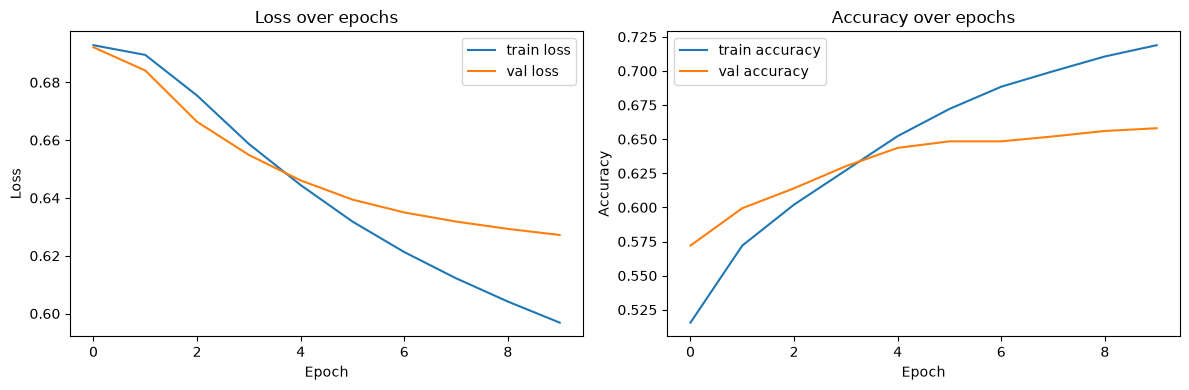

In [ ]:
plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(history.history['loss'], label='train loss')
plt.plot(history.history['val_loss'], label='val loss')
plt.title('Loss over epochs')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history.history['accuracy'], label='train accuracy')
plt.plot(history.history['val_accuracy'], label='val accuracy')
plt.title('Accuracy over epochs')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

plt.tight_layout()
plt.show()

final_train_acc = history.history['accuracy'][-1]
final_val_acc = history.history['val_accuracy'][-1]
final_train_loss = history.history['loss'][-1]
final_val_loss = history.history['val_loss'][-1]
print(f'Q9 interpretation: final train/val loss = {final_train_loss:.4f}/{final_val_loss:.4f}, '
      f'final train/val accuracy = {final_train_acc:.2%}/{final_val_acc:.2%}.')
if final_train_acc - final_val_acc > 0.03:
    print('The growing gap between the training and validation curves shows the model starting to overfit the 30-word sequences.')
else:
    print('Training and validation curves stay close, so the model is not overfitting noticeably over these epochs.')


In [11]:
loss, accuracy = model.evaluate(x_test, y_test, verbose=0)
print('Test loss:', loss)
print('Test accuracy:', accuracy)


'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)


Test loss: 0.6233212351799011
Test accuracy: 0.6652399897575378


9- PLot the loss and accuracy metrics during the training and interpret the result.

In [12]:
# Optional: inspect a few predictions
preds = (model.predict(x_test[:10], verbose=0).ravel() > 0.5).astype(int)
for i, (p, y) in enumerate(zip(preds, y_test[:10])):
    print(i, 'prediction=', p, 'label=', y)


0 prediction= 1 label= 0
1 prediction= 0 label= 1
2 prediction= 0 label= 1
3 prediction= 1 label= 0
4 prediction= 1 label= 1
5 prediction= 0 label= 1
6 prediction= 1 label= 1
7 prediction= 1 label= 0
8 prediction= 1 label= 0
9 prediction= 1 label= 1


'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)


10- Check the accuracy and the loss of your models on the test dataset.

In [13]:
# Evaluate the trained model on the full test set
loss, accuracy = model.evaluate(x_test, y_test, verbose=0)
print('Test loss:', loss)
print('Test accuracy:', accuracy)


Test loss: 0.6233212351799011
Test accuracy: 0.6652399897575378


## Tuning The Vanilla RNN Network


11- Prepare the data to use sequences of length 80 rather than length 30 and retrain your model.  Did it improve the performance?

12- Try different values of the  maximum length of a sequence ("max_features").  Can you improve the performance?

13- Try smaller and larger sizes of the RNN hidden dimension.  How does it affect the model performance?  How does it affect the run time?

In [ ]:
## Q11: use freshly loaded (unpadded) sequences so maxlen=80 keeps more of each review than the maxlen=30 version
maxlen_80 = 80
(x_train_raw, y_train_80), (x_test_raw, y_test_80) = imdb.load_data(num_words=max_features)
x_train_80 = pad_sequences(x_train_raw, maxlen=maxlen_80)
x_test_80 = pad_sequences(x_test_raw, maxlen=maxlen_80)

model_80 = Sequential([
    layers.Embedding(input_dim=max_features, output_dim=50, input_length=maxlen_80),
    layers.SimpleRNN(5, kernel_initializer=initializers.TruncatedNormal(stddev=0.001), activation='tanh'),
    layers.Dense(1, activation='sigmoid')
])
model_80.compile(optimizer=optimizers.RMSprop(learning_rate=1e-4), loss='binary_crossentropy', metrics=['accuracy'])

history_80 = model_80.fit(x_train_80, y_train_80, validation_split=0.2, epochs=5, batch_size=128, verbose=0)
loss_80, acc_80 = model_80.evaluate(x_test_80, y_test_80, verbose=0)
print('maxlen=30 test accuracy:', accuracy)
print('maxlen=80 test accuracy:', acc_80)
print('Q11 conclusion: performance', 'improved' if acc_80 > accuracy else 'did not improve',
      'when increasing maxlen from 30 to 80 (5 epochs each).')

## Q12: vary the vocabulary size (max_features) at a fixed maxlen=30
vocab_results = {}
for vocab_size in (500, 2000, 5000, 10000):
    (xv_train, yv_train), (xv_test, yv_test) = imdb.load_data(num_words=vocab_size)
    xv_train = pad_sequences(xv_train, maxlen=maxlen)
    xv_test = pad_sequences(xv_test, maxlen=maxlen)

    model_v = Sequential([
        layers.Embedding(input_dim=vocab_size, output_dim=50, input_length=maxlen),
        layers.SimpleRNN(5, kernel_initializer=initializers.TruncatedNormal(stddev=0.001), activation='tanh'),
        layers.Dense(1, activation='sigmoid')
    ])
    model_v.compile(optimizer=optimizers.RMSprop(learning_rate=1e-4), loss='binary_crossentropy', metrics=['accuracy'])
    model_v.fit(xv_train, yv_train, validation_split=0.2, epochs=5, batch_size=128, verbose=0)
    _, acc_v = model_v.evaluate(xv_test, yv_test, verbose=0)
    vocab_results[vocab_size] = acc_v
    print(f'max_features={vocab_size} test accuracy:', round(acc_v, 4))

best_vocab = max(vocab_results, key=vocab_results.get)
print(f'Q12 conclusion: the best test accuracy above was obtained with max_features={best_vocab} '
      f'({vocab_results[best_vocab]:.4f}); compare it with max_features=2000 to see whether a bigger vocabulary helps here.')

## Q13: vary the SimpleRNN hidden size at fixed maxlen=30, max_features=2000
hidden_results = {}
for units in (2, 5, 20, 50):
    model_h = Sequential([
        layers.Embedding(input_dim=max_features, output_dim=50, input_length=maxlen),
        layers.SimpleRNN(units, kernel_initializer=initializers.TruncatedNormal(stddev=0.001), activation='tanh'),
        layers.Dense(1, activation='sigmoid')
    ])
    model_h.compile(optimizer=optimizers.RMSprop(learning_rate=1e-4), loss='binary_crossentropy', metrics=['accuracy'])

    start_h = time.time()
    model_h.fit(x_train, y_train, validation_split=0.2, epochs=5, batch_size=128, verbose=0)
    elapsed_h = time.time() - start_h
    _, acc_h = model_h.evaluate(x_test, y_test, verbose=0)
    hidden_results[units] = (acc_h, elapsed_h)
    print(f'hidden units={units} test accuracy:', round(acc_h, 4), 'time (s):', round(elapsed_h, 2))

best_units = max(hidden_results, key=lambda u: hidden_results[u][0])
print(f'Q13 conclusion: hidden size={best_units} gave the best test accuracy ({hidden_results[best_units][0]:.4f}); '
      'larger hidden sizes take longer per run, so weigh the accuracy gain above against the extra training time.')



'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring f

maxlen=80 test accuracy: 0.5406799912452698


## Train LSTM and GRU networks


14- Build LSTM and GRU networks and compare their performance (accuracy and execution time) with the SimpleRNN. What is your conclusion?

In [ ]:
def build_and_train(model_name, layer_type, units, maxlen=maxlen, epochs=3):
    model = Sequential([
        layers.Embedding(input_dim=max_features, output_dim=50, input_length=maxlen),
        layer_type(units, activation='tanh'),
        layers.Dense(1, activation='sigmoid')
    ])
    model.compile(optimizer=optimizers.RMSprop(learning_rate=1e-4), loss='binary_crossentropy', metrics=['accuracy'])

    start = time.time()
    history = model.fit(x_train, y_train, validation_split=0.2, epochs=epochs, batch_size=128, verbose=0)
    elapsed = time.time() - start
    loss, acc = model.evaluate(x_test, y_test, verbose=0)
    print(model_name, 'test accuracy:', round(acc, 4), 'time (s):', round(elapsed, 2))
    return acc, elapsed

# Compare the three recurrent layers.
results = {}
try:
    simple_rnn_acc, simple_rnn_time = build_and_train('SimpleRNN', layers.SimpleRNN, 5, epochs=3)
    results['SimpleRNN'] = (simple_rnn_acc, simple_rnn_time)
except Exception as e:
    print('SimpleRNN failed:', e)

try:
    lstm_acc, lstm_time = build_and_train('LSTM', layers.LSTM, 5, epochs=3)
    results['LSTM'] = (lstm_acc, lstm_time)
except Exception as e:
    print('LSTM failed:', e)

try:
    gru_acc, gru_time = build_and_train('GRU', layers.GRU, 5, epochs=3)
    results['GRU'] = (gru_acc, gru_time)
except Exception as e:
    print('GRU failed:', e)

if results:
    best_model = max(results, key=lambda name: results[name][0])
    fastest_model = min(results, key=lambda name: results[name][1])
    print(f'Q14 conclusion: {best_model} had the highest test accuracy ({results[best_model][0]:.4f}) '
          f'and {fastest_model} was the fastest to train among {list(results.keys())}; '
          'the extra gating in LSTM/GRU costs more time per epoch than SimpleRNN, so pick the layer type '
          'that best trades off accuracy against training time for the task at hand.')



'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring f

SimpleRNN test accuracy: 0.5417 time (s): 5.64


'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring f

LSTM test accuracy: 0.6317 time (s): 6.05
GRU test accuracy: 0.5741 time (s): 5.12
